In [1]:
# ============================================
# Model Evaluation Metrics
# Precision, Recall, AUC
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import load_breast_cancer

# Data splitting
from sklearn.model_selection import train_test_split

# Machine Learning model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

In [2]:
# Load Breast Cancer dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(data.feature_names)

print("\nTarget names:")
print(data.target_names)

Dataset loaded successfully!
Features shape: (569, 30)
Target shape: (569,)

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target names:
['malignant' 'benign']


In [3]:
# Convert dataset into a DataFrame
df = pd.DataFrame(X, columns=data.feature_names)

# Add target column
df["target"] = y

print("First 10 rows:")
display(df.head(10))

print("\nDataset shape:", df.shape)

First 10 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0



Dataset shape: (569, 31)


In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum().sum())

if df.isnull().sum().sum() == 0:
    print("\nNo missing values found.")
else:
    print("\nMissing values are present.")

Missing values in each column:
0

No missing values found.


In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [6]:
# Create Logistic Regression model
model = LogisticRegression(
    max_iter=10000,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
# Predict class labels
y_pred = model.predict(X_test)

# Predict probabilities for positive class
y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted labels:")
print(y_pred)

print("\nPredicted probabilities:")
print(y_prob[:10])

Predicted labels:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]

Predicted probabilities:
[3.26762996e-11 9.99965062e-01 5.04805740e-02 6.04846060e-01
 2.00601520e-09 9.82617339e-01 9.99970060e-01 9.81721401e-06
 4.88003398e-05 1.42322339e-10]


In [8]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

print("======================================")
print("MODEL EVALUATION METRICS")
print("======================================")

print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1 Score  :", round(f1, 4))
print("AUC       :", round(auc, 4))

MODEL EVALUATION METRICS
Accuracy  : 0.9649
Precision : 0.9595
Recall    : 0.9861
F1 Score  : 0.9726
AUC       : 0.9954


In [9]:
# Display detailed classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [10]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[39  3]
 [ 1 71]]


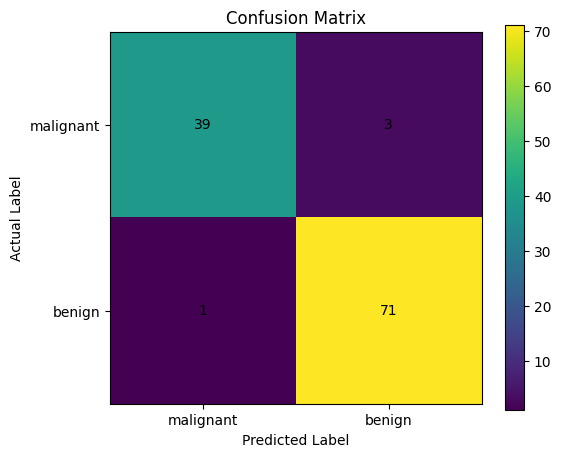

In [11]:
# Visualize confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    data.target_names
)

plt.yticks(
    [0, 1],
    data.target_names
)

# Add values to the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

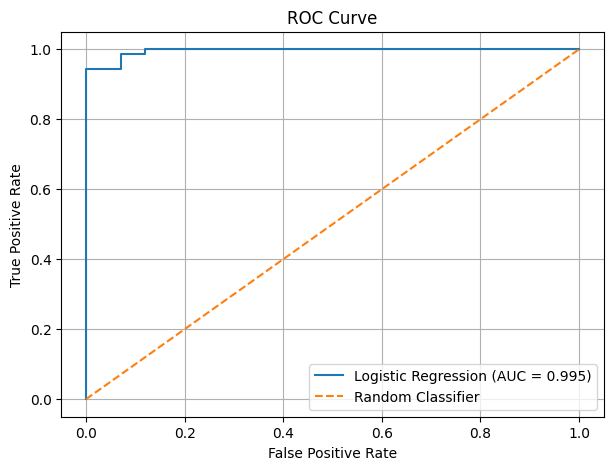

In [12]:
# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

In [13]:
# Store all metrics in a DataFrame

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

display(metrics)

,Metric,Score
0,Accuracy,0.964912
1,Precision,0.959459
2,Recall,0.986111
3,F1 Score,0.972603
4,AUC,0.995370


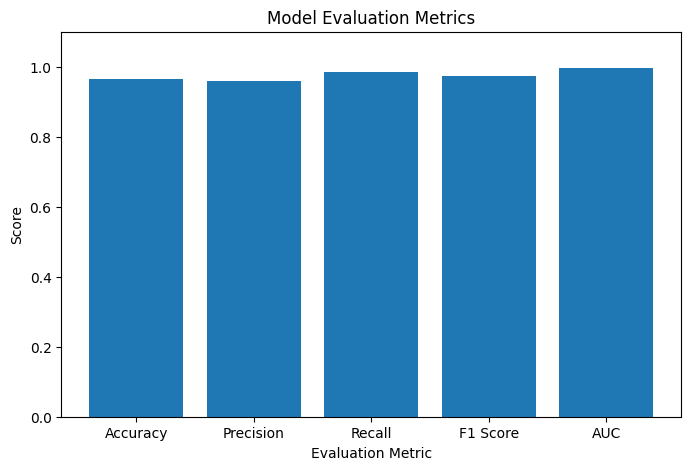

In [14]:
# Plot evaluation metrics

plt.figure(figsize=(8, 5))

plt.bar(
    metrics["Metric"],
    metrics["Score"]
)

plt.ylim(0, 1.1)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.title("Model Evaluation Metrics")

plt.show()

In [15]:
# Final summary of model performance

print("============================================")
print("FINAL MODEL EVALUATION SUMMARY")
print("============================================")

print("Model: Logistic Regression")
print("Dataset: Breast Cancer Dataset")
print("Test Size: 20%")

print("\nEvaluation Results:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")

print("\nModel evaluation completed successfully!")

FINAL MODEL EVALUATION SUMMARY
Model: Logistic Regression
Dataset: Breast Cancer Dataset
Test Size: 20%

Evaluation Results:
Accuracy  : 0.9649
Precision : 0.9595
Recall    : 0.9861
F1 Score  : 0.9726
AUC       : 0.9954

Model evaluation completed successfully!
